In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'torch', 'torchvision']
imports = {'pillow': 'PIL'}
pinned = {}
fallbacks = {'torch': 'torch==2.11.0', 'torchvision': 'torchvision==0.26.0'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'torch.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Memory and Precision

So far this chapter has fought for *time*: fewer memory round trips, fewer
kernel launches, more arithmetic per byte. This section fights for *space*.
Sooner or later a model stops fitting: the optimizer states, the
activations held for the backward pass, and a large enough batch together
overflow the card, and training dies with an out-of-memory error long
before it is slow. The good news is that memory is the most *legible* of
the resources — you can write down exactly where every byte of a training
step goes, measure it against that prediction, and then spend three
well-understood techniques to buy headroom: lower-precision formats, which
also buy speed; activation checkpointing, which trades compute for memory;
and gradient accumulation, which trades *time* for the effect of a bigger
batch. Together these are the "it doesn't fit" rung of the ladder, and
they are what stands between a 24 GB card and a model that wants 30.

*Prerequisites: the format ladder and tensor-core requirement of*
that section*; the* `d2l.Benchmark` *timer of*
that section*; the AdamW optimizer states of*
that section*. This section finally discharges the "gradient
accumulation, returned to in the performance chapter" promise of*
that section*.*

In [1]:
%matplotlib inline
from d2l import torch as d2l
import torch
from torch import nn

torch.set_float32_matmul_precision('high')

## The Memory Anatomy of a Training Step

A training step holds four kinds of tensor in memory, and knowing their
sizes lets you predict the peak before you run anything
(the figure). Let the model have $P$ parameters.

* **Parameters** — $P$ values. In mixed-precision training these are kept
  in fp32 (4 bytes) as the master copy: $4P$ bytes.
* **Gradients** — one per parameter, produced during the backward pass:
  another $4P$ bytes.
* **Optimizer states** — Adam keeps a first and second moment per
  parameter (that section), $2 \times 4P = 8P$ bytes; plain SGD
  keeps none.
* **Activations** — every intermediate result the forward pass produces
  that the backward pass will need. Unlike the first three, this scales
  with the *batch* and the *depth*: roughly
  $\textrm{batch} \times \textrm{sequence} \times \textrm{width} \times
  \textrm{depth}$, and it is usually the term that blows up.

![Where a training step's memory goes, over the step timeline. Parameters
and optimizer states are constant; activations grow through the forward
pass and are released through the backward pass; gradients fill in as
they are computed. Peak memory lands early in the backward pass, when
activations are still full.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-perf-memory-anatomy.svg)

Add the constant terms: training a model with Adam costs about
$4P + 4P + 8P = 16P$ bytes *before a single activation* — sixteen bytes
per parameter, the number to carry in your head. (Mixed precision, below,
nudges this to roughly 18–20 by keeping some tensors in two formats; it
still saves memory overall, because activations, the dominant term,
halve.) The shape of the figure is the other half of the
lesson: activations *accumulate* through the forward pass and are *freed*
as the backward pass consumes them, so peak memory occurs early in
backward — which is exactly the moment activation checkpointing will
target.

## Measuring Memory

The frameworks let you check the anatomy against reality, and — as with
timing — the two do it in characteristically different ways. PyTorch keeps
running *counters* you query at runtime; JAX lets the compiler *plan*
memory ahead of time and reports the plan. Start with PyTorch's counters,
the numbers the anatomy table predicts:

In [2]:
gpu = d2l.try_gpu()
net = nn.Sequential(*[nn.Linear(2048, 2048) for _ in range(6)]).to(gpu)
X = torch.randn(256, 2048, device=gpu)
opt = torch.optim.Adam(net.parameters())

torch.cuda.reset_peak_memory_stats()
opt.zero_grad(set_to_none=True)
net(X).sum().backward()
opt.step()
P = sum(p.numel() for p in net.parameters())
print(f'{P/1e6:.1f}M params  '
      f'predicted states+grads+params: {16 * P / 1e6:.0f} MB')
print(f'measured peak: {torch.cuda.max_memory_allocated() / 1e6:.0f} MB '
      f'allocated, {torch.cuda.max_memory_reserved() / 1e6:.0f} MB reserved')

25.2M params  predicted states+grads+params: 403 MB
measured peak: 524 MB allocated, 547 MB reserved


The measured peak overshoots the $16P$ prediction by roughly 30%, and the
gap has an anatomy of its own: this stack's activations (about 13 MB),
autograd bookkeeping and cuBLAS workspaces, temporaries that the fused
optimizer update allocates (about the size of one more gradient set), and
the caching allocator's block rounding. The second printed number is
larger again: `max_memory_allocated` counts bytes inside live tensors,
while `max_memory_reserved` is the caching allocator's high-water mark —
the distinction that section dissects. So read $16P$ as this
*configuration's* floor — fp32 parameters under Adam — rather than as the
whole anatomy; and whether activations dominate the total, as they do in
the transformer regime, is workload-dependent: batch, sequence length,
and depth decide.

For a finer picture, PyTorch can record every allocation and free as a
*snapshot*. Rather than embed its interactive viewer, we reconstruct the
one plot that matters — allocated bytes over the step — directly from the
recorded trace, and see the sawtooth of the figure in
real data:

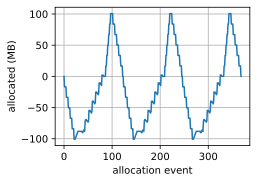

In [3]:
torch.cuda.memory._record_memory_history(max_entries=100000)
for _ in range(3):
    opt.zero_grad(set_to_none=True)
    net(X).sum().backward()
    opt.step()
snapshot = torch.cuda.memory._snapshot()
torch.cuda.memory._record_memory_history(enabled=None)

# Reconstruct cumulative allocated bytes from the allocation trace.
cum, series = 0, []
for ev in snapshot['device_traces'][0]:
    if ev['action'] == 'alloc':
        cum += ev['size']
    elif ev['action'] == 'free_completed':
        cum -= ev['size']
    series.append(cum / 1e6)
d2l.plot(list(range(len(series))), [series],
         'allocation event', 'allocated (MB)')

Each cycle is one training step: memory climbs through the forward pass as
activations accumulate, then falls through the backward pass as they are
released — exactly the anatomy, now measured. The JAX side plans instead
of counts. Ahead-of-time compilation (that section) hands
back an object whose `memory_analysis()` reports what the compiler
*decided* to allocate, before any memory is touched:

The contrast is worth stating plainly: **PyTorch counts allocations as
they happen; XLA plans memory at compile time.** Neither is better; they
reflect the eager-versus-traced split of that section, and
knowing which mental model your framework uses tells you where to look
when memory surprises you. Just do not compare the two frameworks' digits
head-to-head: a compiler's plan is not an allocator's high-water mark.

## Mixed Precision

The format ladder of that section promised that every halving of
width wins twice — double the tensor-core throughput and half the bytes.
Mixed precision cashes that promise for training. The idea: run the
compute-heavy operations (matmuls, convolutions) in bf16, where tensor
cores are fastest and activations are half-size, while keeping a few
numerically delicate things (the master weights, the loss reduction) in
fp32. On our Ada card the arithmetic win is real and robust — but only if
you know what your baseline is running, the lesson that section
flagged. Whether plain fp32 matmuls use the tensor cores' tf32 path is a
framework default: PyTorch ships with tf32 *off*, so a naive fp32
baseline is needlessly slow and inflates the apparent speedup; JAX on
this card runs tf32-class dot compute *by default*, so its naive baseline
is already fair — but is not the true fp32 it appears to be. We time all
three configurations, once, so the difference is unmistakable:

In [4]:
net = nn.Sequential(nn.Flatten(),
                    nn.Linear(64 * 64, 8192), nn.ReLU(),
                    nn.Linear(8192, 8192), nn.ReLU(),
                    nn.Linear(8192, 10)).to(gpu)
X = torch.randn(2048, 1, 64, 64, device=gpu)
y = torch.randint(0, 10, (2048,), device=gpu)
opt = torch.optim.SGD(net.parameters(), lr=0.01)
loss = nn.CrossEntropyLoss()

def step(autocast, dtype=None):
    opt.zero_grad(set_to_none=True)
    if autocast:
        with torch.autocast('cuda', dtype=dtype):
            l = loss(net(X), y)
    else:
        l = loss(net(X), y)
    l.backward(); opt.step()

torch.set_float32_matmul_precision('highest')  # Unfair baseline: tf32 off
print(d2l.Benchmark(lambda: step(False), desc='fp32 (tf32 off)'))
torch.set_float32_matmul_precision('high')     # Fair baseline: tf32 on
print(d2l.Benchmark(lambda: step(False), desc='tf32'))
print(d2l.Benchmark(lambda: step(True, torch.bfloat16), desc='bf16 autocast'))

fp32 (tf32 off): 22.58 ms/call


tf32: 17.79 ms/call


bf16 autocast: 9.78 ms/call


Against the fair tf32 baseline, bf16 runs about one and a half to two
times as fast here — the exact ratio is framework- and shape-dependent —
and the three timings tell the same two-step story in both tabs: moving
true fp32 dots onto the tf32 tensor cores already buys a sizable step,
and bf16 then adds at least as much again. Both are genuine tensor-core
wins, not measurement artifacts.
Note what the PyTorch tab does *not* use: a `GradScaler`. Loss scaling
exists to keep tiny fp16 gradients from underflowing fp16's narrow
5-bit-exponent range; bf16 shares fp32's 8-bit exponent
(the figure), so its gradients do not underflow and no
scaler is needed. fp16-plus-`GradScaler` is the pre-Ampere legacy path,
worth one sentence and an exercise. The JAX tab makes the philosophical
difference visible: precision in JAX is *explicit* — you thread dtypes
through the computation, and `jax.default_matmul_precision` sets how fp32
dots are *computed* (true fp32 versus tf32-class tensor-core compute)
without changing what any tensor *stores*. On this card JAX's default
matches `'high'`, tf32-class, bit for bit — which is why the middle
timing is the fair baseline. PyTorch decides per-operation what to cast;
JAX makes you say it. Both land on the same design point: bf16 halves the
bytes and doubles the tensor-core rate.

## Activation Checkpointing

Mixed precision halves activation memory; activation checkpointing can cut
it much further, by refusing to *store* most activations at all. Recall
from the figure that activations are held from the
moment the forward pass produces them until the backward pass consumes
them — that storage is the peak. Checkpointing makes a different trade:
store only a few activations (at block boundaries), and when the backward
pass needs the ones in between, *recompute them* by re-running that block's
forward pass. You pay extra compute — at most one extra forward pass — to
avoid holding a large fraction of the activations; the cells below
measure both sides of the trade. This is the same
"recompute rather than store" argument the
Mamba kernel of that section made one level down in the hardware
[@Chen.Xu.Zhang.ea.2016].

In [5]:
from torch.utils.checkpoint import checkpoint

class Block(nn.Module):
    def __init__(self, d=1024):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d, d), nn.GELU(), nn.Linear(d, d))
    def forward(self, x):
        return x + self.net(x)

blocks = nn.ModuleList([Block().to(gpu) for _ in range(16)])
X = torch.randn(16384, 1024, device=gpu, requires_grad=True)

def run(use_ckpt):
    h = X
    for blk in blocks:
        # use_reentrant=False is the modern, mandatory-since-2.9 form
        h = checkpoint(blk, h, use_reentrant=False) if use_ckpt else blk(h)
    return h.sum()

for use_ckpt in (False, True):
    for p in blocks.parameters():  # clear grads so the peaks are comparable
        p.grad = None
    X.grad = None
    torch.cuda.reset_peak_memory_stats()
    run(use_ckpt).backward()
    peak = torch.cuda.max_memory_allocated() / 1e6
    t = d2l.Benchmark(lambda: run(use_ckpt).backward()).time
    tag = 'checkpointed' if use_ckpt else 'store all'
    print(f'{tag}: peak {peak:.0f} MB, fwd+bwd {1000 * t:.1f} ms')

store all: peak 4318 MB, fwd+bwd 59.9 ms


checkpointed: peak 2306 MB, fwd+bwd 71.1 ms


Checkpointing releases about 2 GB of held activations on this 16-block
stack — the measured peak falls by nearly half in the allocator's count
and by more than half in the compiler's plan — and the completion-timed
step runs only about 15–20% longer, comfortably under the one-extra-forward bound, since the
backward pass dominates the step. It is a trade you make when memory is
the binding constraint: checkpointing normally costs time, and its
purpose is memory (the rare configurations where recomputation beats a
cache-hostile stash do not change the rule). JAX exposes the same
mechanism as `jax.checkpoint` (equivalently `jax.remat`), with a nicer
knob: policies like `checkpoint_dots` let you say *which* intermediates to
keep, and `jax.remat`'s companion tools let you *watch* what was saved —
the introspection theme JAX does uniquely well. The trade is identical;
the interface reflects each framework's temperament, imperative versus
declarative.

## Gradient Accumulation

The final technique buys the *statistical* effect of a large batch without
its memory cost — and discharges a promise made all the way back in
that section. A large batch improves gradient estimates and
tensor-core utilization (its intensity is higher, that section),
but a large batch's activations may not fit. Gradient accumulation splits
the desired *global* batch into $k$ *micro-batches*, runs forward and
backward on each while *summing* the gradients, and only then takes one
optimizer step. The activations of just one micro-batch are live at a
time, so peak memory follows the micro-batch, while the update sees the
full global batch: $B_{\textrm{global}} = B_{\textrm{micro}} \times k$
(times the number of devices, once that section adds them). The
parity check — that accumulating $k$ micro-batches matches one full-batch
step — is worth seeing, because it is the whole correctness claim:

In [6]:
net = nn.Linear(1024, 1).to(gpu)
X = torch.randn(128, 1024, device=gpu)
y = torch.randn(128, 1, device=gpu)
loss = nn.MSELoss()

# Full batch: one backward over all 128 rows.
net.zero_grad()
loss(net(X), y).backward()
full = net.weight.grad.clone()

# Accumulated: 4 micro-batches of 32, gradients summed, scaled by 1/4.
net.zero_grad()
for i in range(4):
    xb, yb = X[i * 32:(i + 1) * 32], y[i * 32:(i + 1) * 32]
    (loss(net(xb), yb) / 4).backward()   # /4 because MSE already averages
accumulated = net.weight.grad.clone()
print(f'max gradient difference: {(full - accumulated).abs().max():.2e}')

max gradient difference: 1.19e-07


The gradients match to floating-point noise. The one subtlety is the
averaging: if your loss already averages over the batch (as MSE and
cross-entropy do), each micro-batch gradient must be scaled by $1/k$ so
the sum reproduces the mean. The equivalence also rests on conditions
this tiny example satisfies silently: an additive per-example loss,
equal-size micro-batches (or a properly weighted mean), the same dropout
and RNG draws, no batch-coupled state such as BatchNorm — whose
statistics would be computed per micro-batch — and clipping or optimizer
steps applied only at the global boundary. Accumulation is the right tool
when you are memory-bound and want a bigger *effective* batch; it is the
wrong tool when you want to go faster: the arithmetic is identical but
arrives as more launches over smaller, lower-intensity GEMMs, so by this
chapter's own accounting it is usually slightly *slower* — it only
rearranges *when* the optimizer step happens.

## The Ladder So Far

Four sections in, the escalation is worth naming as a checklist. When a
model does not fit or does not run fast enough, in order of cost:

1. **It's slow, bandwidth- or overhead-bound** → compile it
   (that section). Usually free.
2. **It's slow, compute-bound, or it's tight on memory** → drop to bf16
   (mixed precision). Around $1.5$–$2\times$ speed and half the
   activation bytes.
3. **It still doesn't fit** → checkpoint activations. Large memory saving
   for a modest increase in time.
4. **It still doesn't fit, and you want a bigger effective batch** →
   accumulate gradients. Bigger effective batch at micro-batch memory —
   about the same wall-clock, never faster.
5. **It's still too slow, or genuinely too big for one card** → add
   devices (that section).

The next section takes that last step — and finds that adding devices is
where the accounting gets hardest.

## Summary

* A training step's memory is parameters ($4P$) + gradients ($4P$) +
  optimizer states (Adam: $8P$) + activations (batch × depth × width, the
  term that explodes). About $16P$ bytes before activations; peak lands
  early in the backward pass.
* PyTorch measures memory with runtime counters and allocation snapshots;
  JAX reports the compiler's ahead-of-time memory *plan*. Counting versus
  planning — the eager-versus-traced split again.
* Mixed-precision bf16 raises tensor-core throughput (1.5–2× over a fair
  tf32 baseline here, framework- and shape-dependent) and halves
  activation bytes; measure it against that *fair* tf32 baseline — the
  frameworks' fp32 defaults differ — and skip the `GradScaler` (bf16
  shares fp32's exponent range — only fp16 needs loss scaling).
* Activation checkpointing recomputes instead of stores: peak memory cut
  roughly in half or better on a deep stack (about 2 GB of activations
  released) for about 15–20% more step time here. It normally costs time; its
  purpose is memory — use it when memory binds.
* Gradient accumulation reaches a large *effective* batch at micro-batch
  memory cost — $B_{\textrm{global}} = B_{\textrm{micro}} \times k$ — at
  the same wall-clock; scale per-micro-batch losses by $1/k$ when the loss
  already averages.

## Exercises

1. Take the GPT of that section and, using only the anatomy of
   that section, compute the largest $(\textrm{width},
   \textrm{depth})$ trainable in 24 GB under three regimes: fp32 + Adam,
   bf16 + Adam, bf16 + Adam + checkpointing (assume activations dominate).
   Then verify one point against `max_memory_allocated`.
1. Derive the per-token activation bytes of one `TransformerBlock`
   (that section) as a function of width and sequence length, and
   check your formula against the measured peak from the snapshot plot.
1. Implement "checkpoint every $\sqrt{n}$-th block" for the deep block
   stack above and measure peak memory and step time. Why is $\sqrt{n}$ the
   memory-optimal checkpointing interval?
1. Break fp16 (not bf16) deliberately: construct a step whose gradients
   are small enough to underflow fp16's subnormal floor (e.g., scale the
   loss by $10^{-4}$ before calling backward), run it under
   `torch.autocast(dtype=torch.float16)` without a `GradScaler`, and
   verify that gradients flush to zero while the same step under bf16
   survives. Then enable a `GradScaler`, confirm the gradients return,
   and explain what the scaler did in terms of
   the figure. Why does a full training run fail this
   way only *sometimes* — what makes the failure workload-dependent?
1. With a fixed global batch of 512, sweep the micro-batch size $\in
   \{512, 256, 128, 64\}$ (so $k \in \{1, 2, 4, 8\}$), and plot peak
   memory and wall-clock per optimizer step. Confirm that memory follows
   the micro-batch while the update is unchanged, and explain the small
   time overhead of large $k$.